In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import xgboost as xgb
import catboost as cb
import pickle

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.columns)
print(test.columns)

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')
Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered'],
      dtype='object')


In [3]:
# Convert datetime
train['datetime'] = pd.to_datetime(train['datetime'], errors='coerce')
test['datetime'] = pd.to_datetime(test['datetime'], errors='coerce')

In [4]:
# Extract features
for df in [train, test]:
    df['hour'] = df['datetime'].dt.hour
    df['day'] = df['datetime'].dt.day
    df['month'] = df['datetime'].dt.month
    df['year'] = df['datetime'].dt.year
    df['dayofweek'] = df['datetime'].dt.dayofweek

In [5]:
# Drop columns that leak target information
train = train.drop(['datetime', 'casual', 'registered'], axis=1)

# Save datetime for submission
test_datetime = test['datetime']
test = test.drop(['datetime'], axis=1)

In [6]:
# Prepare target and features
y = np.log1p(train['count'])
X = train.drop('count', axis=1)

In [7]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Dictionary to store models and their validation scores
models = {}
validation_scores = {}


Training Gradient Boosting Regressor...
Validation RMSLE: 0.282390


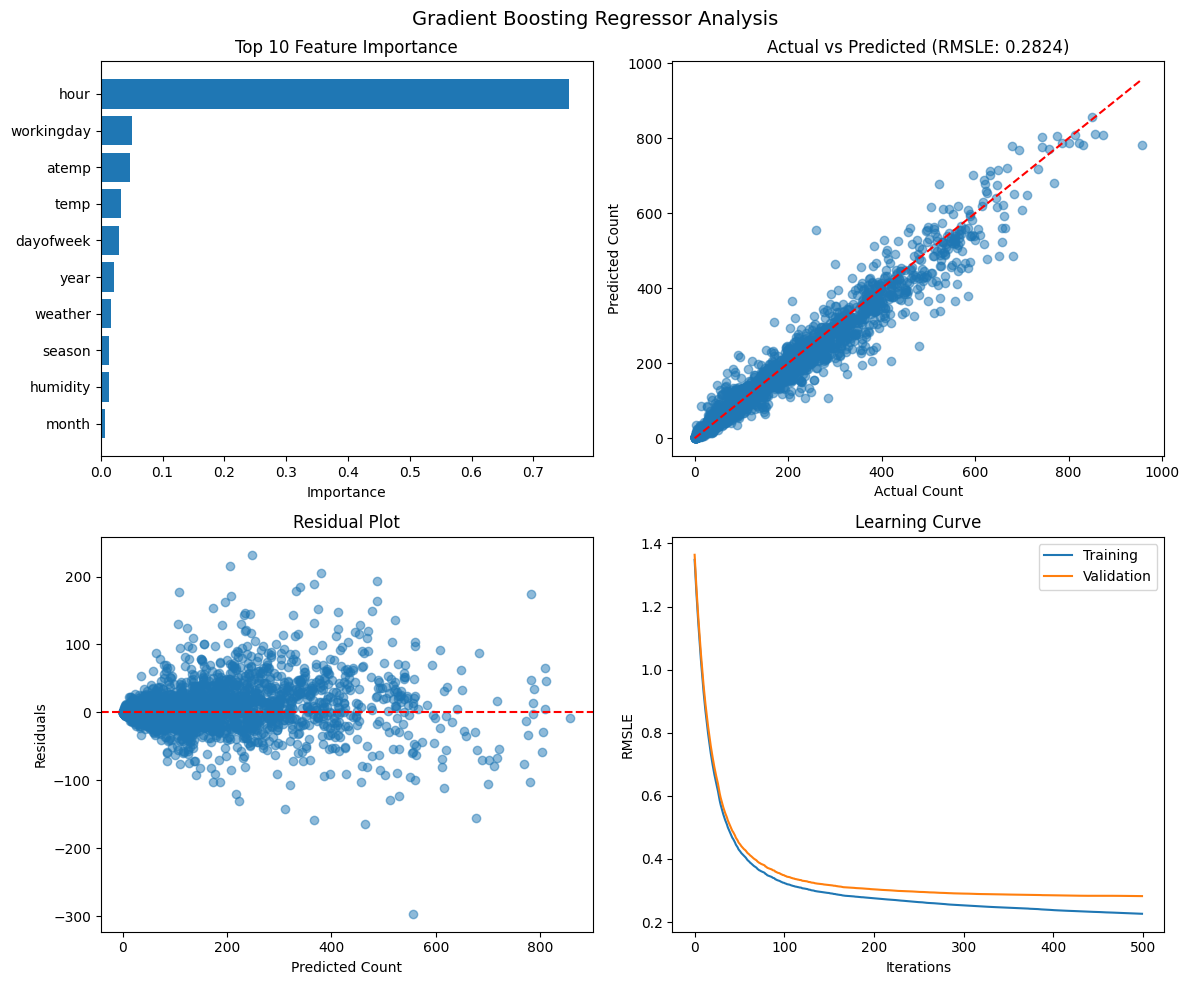

In [9]:
# 1. Gradient Boosting (Original)
print("\n" + "="*50)
print("Training Gradient Boosting Regressor...")
print("="*50)

gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)
val_pred_gb = gb_model.predict(X_val)
rmsle_gb = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(val_pred_gb)))
print(f"Validation RMSLE: {rmsle_gb:.6f}")

models['GradientBoosting'] = gb_model
validation_scores['GradientBoosting'] = rmsle_gb

# Plot for Gradient Boosting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Gradient Boosting Regressor Analysis', fontsize=14)

# Feature Importance
feature_importance = gb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)[-10:]
axes[0, 0].barh(range(10), feature_importance[sorted_idx])
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels([X.columns[i] for i in sorted_idx])
axes[0, 0].set_title('Top 10 Feature Importance')
axes[0, 0].set_xlabel('Importance')

# Actual vs Predicted
axes[0, 1].scatter(np.expm1(y_val), np.expm1(val_pred_gb), alpha=0.5)
axes[0, 1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'r--')
axes[0, 1].set_xlabel('Actual Count')
axes[0, 1].set_ylabel('Predicted Count')
axes[0, 1].set_title(f'Actual vs Predicted (RMSLE: {rmsle_gb:.4f})')

# Residuals
residuals = np.expm1(y_val) - np.expm1(val_pred_gb)
axes[1, 0].scatter(np.expm1(val_pred_gb), residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Count')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')

# Learning Curve
train_errors = []
val_errors = []
for y_pred_train in gb_model.staged_predict(X_train):
    train_errors.append(np.sqrt(mean_squared_log_error(np.expm1(y_train), np.expm1(y_pred_train))))
for y_pred_val in gb_model.staged_predict(X_val):
    val_errors.append(np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(y_pred_val))))

axes[1, 1].plot(train_errors, label='Training')
axes[1, 1].plot(val_errors, label='Validation')
axes[1, 1].set_xlabel('Iterations')
axes[1, 1].set_ylabel('RMSLE')
axes[1, 1].set_title('Learning Curve')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('gradient_boosting_plots.png')
plt.show()



Training Random Forest Regressor...
Validation RMSLE: 0.439985


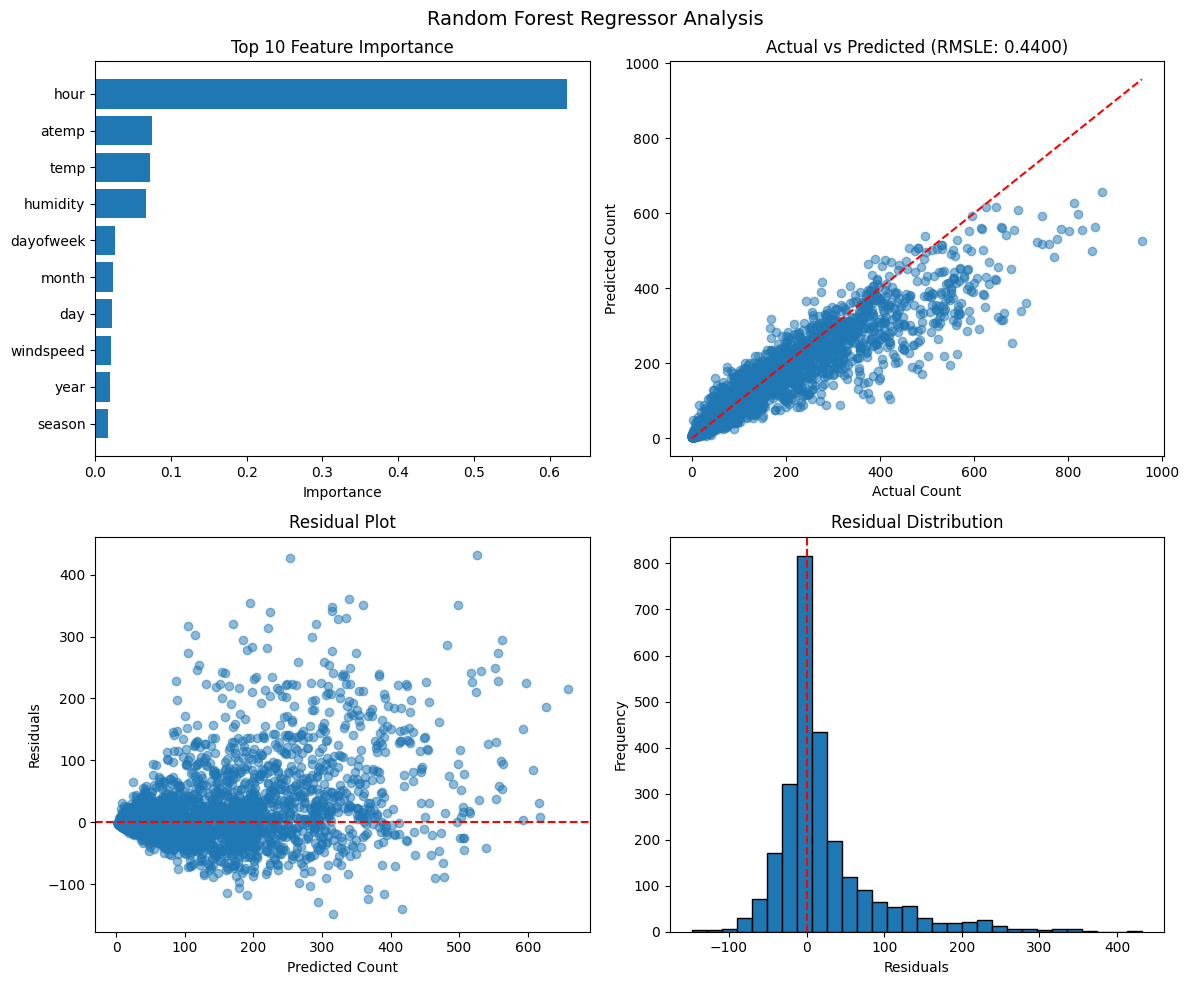

In [10]:
# 2. Random Forest
print("\n" + "="*50)
print("Training Random Forest Regressor...")
print("="*50)

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
val_pred_rf = rf_model.predict(X_val)
rmsle_rf = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(val_pred_rf)))
print(f"Validation RMSLE: {rmsle_rf:.6f}")

models['RandomForest'] = rf_model
validation_scores['RandomForest'] = rmsle_rf

# Plot for Random Forest
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Random Forest Regressor Analysis', fontsize=14)

# Feature Importance
feature_importance = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importance)[-10:]
axes[0, 0].barh(range(10), feature_importance[sorted_idx])
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels([X.columns[i] for i in sorted_idx])
axes[0, 0].set_title('Top 10 Feature Importance')
axes[0, 0].set_xlabel('Importance')

# Actual vs Predicted
axes[0, 1].scatter(np.expm1(y_val), np.expm1(val_pred_rf), alpha=0.5)
axes[0, 1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'r--')
axes[0, 1].set_xlabel('Actual Count')
axes[0, 1].set_ylabel('Predicted Count')
axes[0, 1].set_title(f'Actual vs Predicted (RMSLE: {rmsle_rf:.4f})')

# Residuals
residuals = np.expm1(y_val) - np.expm1(val_pred_rf)
axes[1, 0].scatter(np.expm1(val_pred_rf), residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Count')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')

# Error Distribution
axes[1, 1].hist(residuals, bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('random_forest_plots.png')
plt.show()


Training XGBoost Regressor...
Validation RMSLE: 0.277318


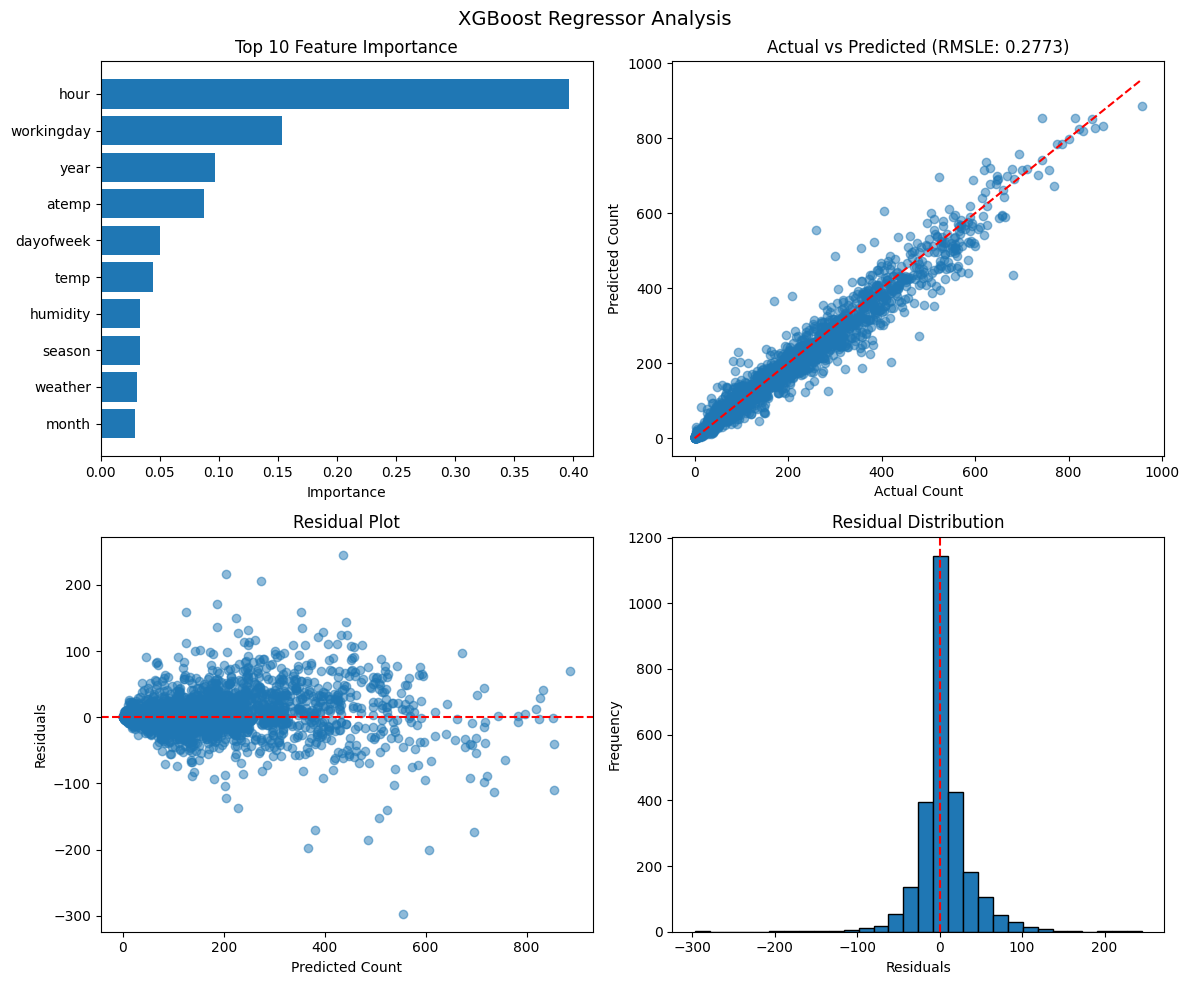

In [11]:
# 3. XGBoost
print("\n" + "="*50)
print("Training XGBoost Regressor...")
print("="*50)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
val_pred_xgb = xgb_model.predict(X_val)
rmsle_xgb = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(val_pred_xgb)))
print(f"Validation RMSLE: {rmsle_xgb:.6f}")

models['XGBoost'] = xgb_model
validation_scores['XGBoost'] = rmsle_xgb

# Plot for XGBoost
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('XGBoost Regressor Analysis', fontsize=14)

# Feature Importance
feature_importance = xgb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)[-10:]
axes[0, 0].barh(range(10), feature_importance[sorted_idx])
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels([X.columns[i] for i in sorted_idx])
axes[0, 0].set_title('Top 10 Feature Importance')
axes[0, 0].set_xlabel('Importance')

# Actual vs Predicted
axes[0, 1].scatter(np.expm1(y_val), np.expm1(val_pred_xgb), alpha=0.5)
axes[0, 1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'r--')
axes[0, 1].set_xlabel('Actual Count')
axes[0, 1].set_ylabel('Predicted Count')
axes[0, 1].set_title(f'Actual vs Predicted (RMSLE: {rmsle_xgb:.4f})')

# Residuals
residuals = np.expm1(y_val) - np.expm1(val_pred_xgb)
axes[1, 0].scatter(np.expm1(val_pred_xgb), residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Count')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')

# Error Distribution
axes[1, 1].hist(residuals, bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('xgboost_plots.png')
plt.show()


Training CatBoost Regressor...
Validation RMSLE: 0.282540


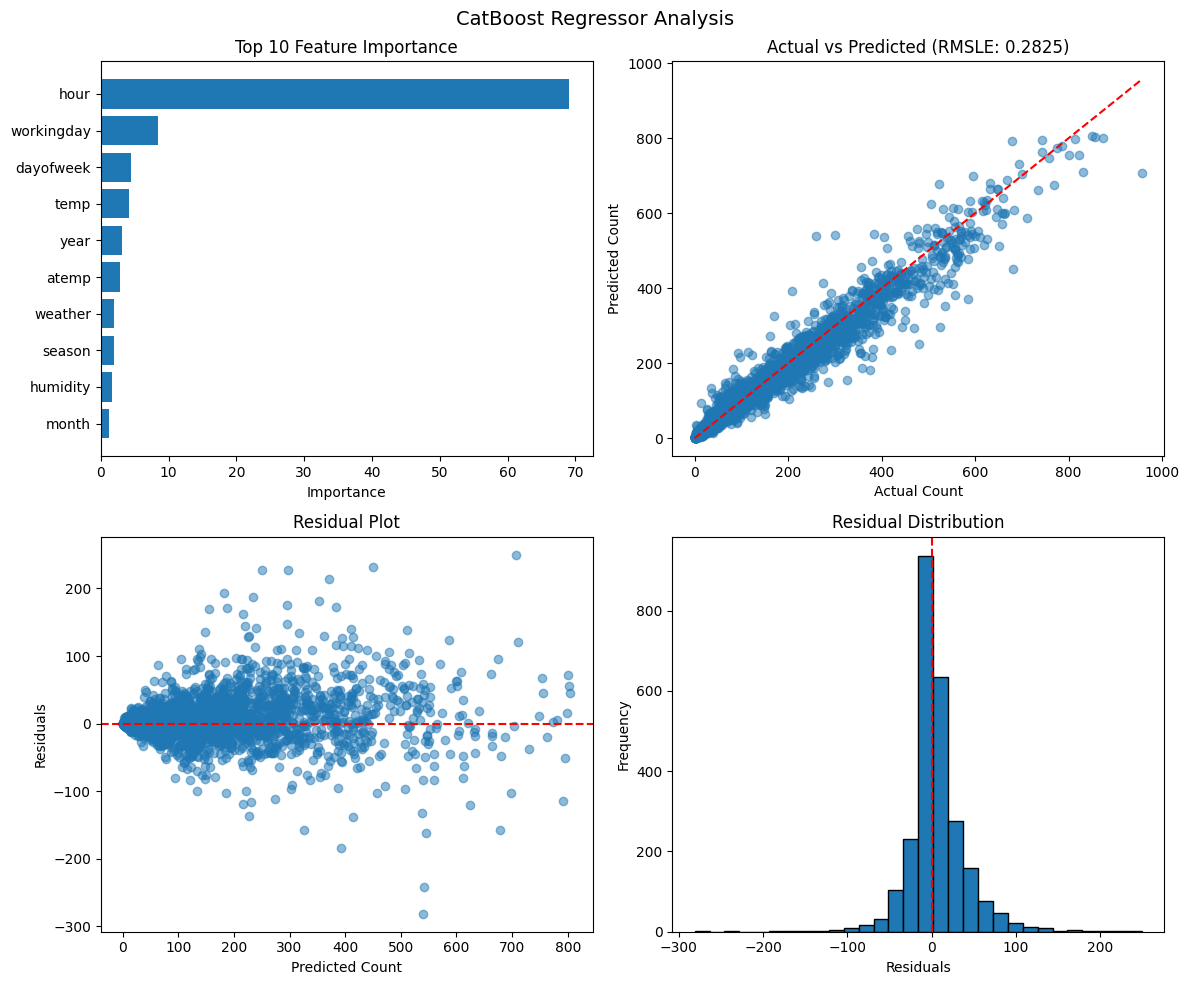

In [12]:
# 4. CatBoost
print("\n" + "="*50)
print("Training CatBoost Regressor...")
print("="*50)

cb_model = cb.CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=100,
    random_seed=42
)

cb_model.fit(X_train, y_train, verbose=False)
val_pred_cb = cb_model.predict(X_val)
rmsle_cb = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(val_pred_cb)))
print(f"Validation RMSLE: {rmsle_cb:.6f}")

models['CatBoost'] = cb_model
validation_scores['CatBoost'] = rmsle_cb

# Plot for CatBoost
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('CatBoost Regressor Analysis', fontsize=14)

# Feature Importance
feature_importance = cb_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-10:]
axes[0, 0].barh(range(10), feature_importance[sorted_idx])
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels([X.columns[i] for i in sorted_idx])
axes[0, 0].set_title('Top 10 Feature Importance')
axes[0, 0].set_xlabel('Importance')

# Actual vs Predicted
axes[0, 1].scatter(np.expm1(y_val), np.expm1(val_pred_cb), alpha=0.5)
axes[0, 1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'r--')
axes[0, 1].set_xlabel('Actual Count')
axes[0, 1].set_ylabel('Predicted Count')
axes[0, 1].set_title(f'Actual vs Predicted (RMSLE: {rmsle_cb:.4f})')

# Residuals
residuals = np.expm1(y_val) - np.expm1(val_pred_cb)
axes[1, 0].scatter(np.expm1(val_pred_cb), residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Count')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')

# Error Distribution
axes[1, 1].hist(residuals, bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('catboost_plots.png')
plt.show()



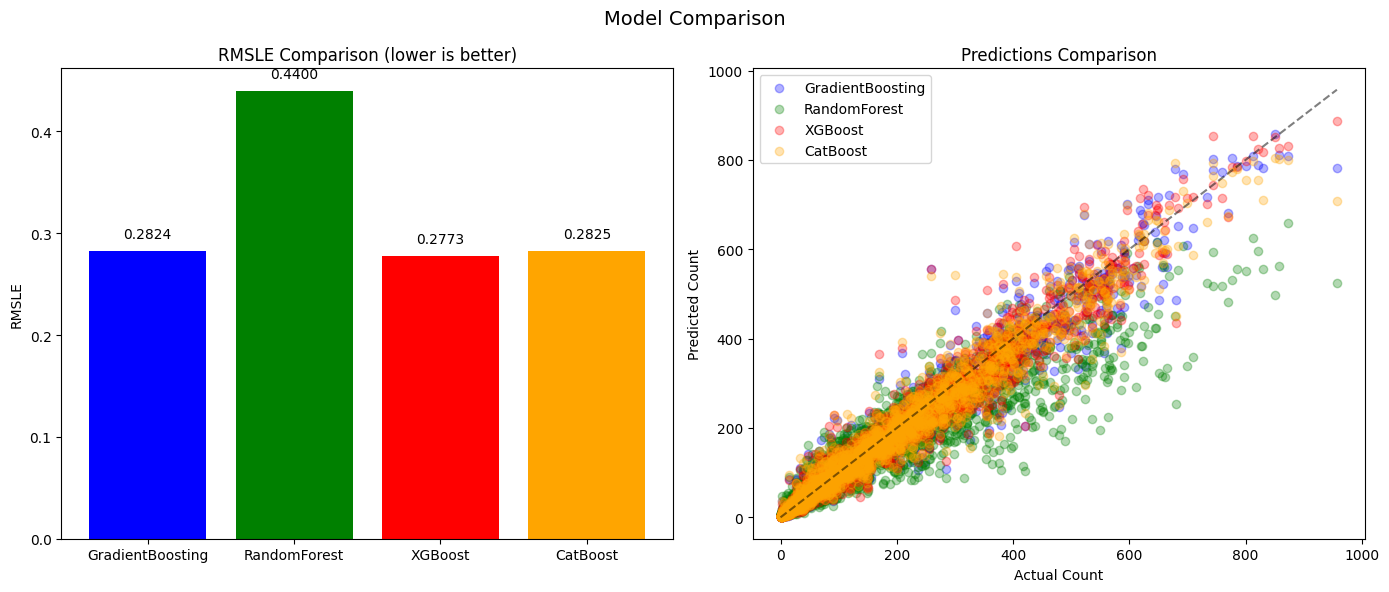

In [13]:
# Model Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison', fontsize=14)

# RMSLE Comparison
models_list = list(validation_scores.keys())
scores_list = list(validation_scores.values())
colors = ['blue', 'green', 'red', 'orange']
bars = axes[0].bar(models_list, scores_list, color=colors)
axes[0].set_ylabel('RMSLE')
axes[0].set_title('RMSLE Comparison (lower is better)')
for bar, score in zip(bars, scores_list):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', va='bottom')

# Predictions Comparison
for i, (name, model) in enumerate(models.items()):
    pred = np.expm1(model.predict(X_val))
    axes[1].scatter(np.expm1(y_val), pred, alpha=0.3, label=name, color=colors[i])
axes[1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'k--', alpha=0.5)
axes[1].set_xlabel('Actual Count')
axes[1].set_ylabel('Predicted Count')
axes[1].set_title('Predictions Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [14]:
# Display all validation scores
print("\n" + "="*50)
print("Validation RMSLE Scores Summary")
print("="*50)
for model_name, score in validation_scores.items():
    print(f"{model_name:20s}: {score:.6f}")


Validation RMSLE Scores Summary
GradientBoosting    : 0.282390
RandomForest        : 0.439985
XGBoost             : 0.277318
CatBoost            : 0.282540


In [15]:
# Find best model
best_model_name = min(validation_scores, key=validation_scores.get)
print(f"\nBest Model: {best_model_name} with RMSLE: {validation_scores[best_model_name]:.6f}")


Best Model: XGBoost with RMSLE: 0.277318


In [16]:
# Retrain best model on full dataset
print(f"\nRetraining {best_model_name} on full dataset...")
best_model = models[best_model_name]
best_model.fit(X, y)

# Save all models
print("\n" + "="*50)# Retrain best model on full dataset
print(f"\nRetraining {best_model_name} on full dataset...")
best_model = models[best_model_name]
best_model.fit(X, y)

# Save all models
print("\n" + "="*50)
print("Saving models...")
print("="*50)

# Save individual models
for model_name, model in models.items():
    filename = f"bike_model_{model_name.lower()}.pkl"
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"✓ {filename} saved")

# Save the best model separately
best_filename = f"bike_model_best_{best_model_name.lower()}.pkl"
with open(best_filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f"\n✓ Best model saved as: {best_filename}")

# Also save all models in a dictionary for easy access
all_models_filename = "bike_models_all.pkl"
with open(all_models_filename, 'wb') as f:
    pickle.dump(models, f)
print(f"✓ All models saved in: {all_models_filename}")

print("\n✅ All models saved successfully!")
print("Saving models...")
print("="*50)


Retraining XGBoost on full dataset...


Retraining XGBoost on full dataset...

Saving models...
✓ bike_model_gradientboosting.pkl saved
✓ bike_model_randomforest.pkl saved
✓ bike_model_xgboost.pkl saved
✓ bike_model_catboost.pkl saved

✓ Best model saved as: bike_model_best_xgboost.pkl
✓ All models saved in: bike_models_all.pkl

✅ All models saved successfully!
Saving models...


In [17]:
# Optional: Create ensemble prediction (simple average)
print("\n" + "="*50)
print("Creating ensemble predictions...")
print("="*50)

# Make predictions on validation set with all models
ensemble_pred_val = np.zeros_like(val_pred_gb)
for model in models.values():
    ensemble_pred_val += model.predict(X_val)
ensemble_pred_val /= len(models)

rmsle_ensemble = np.sqrt(mean_squared_log_error(
    np.expm1(y_val), 
    np.expm1(ensemble_pred_val)
))
print(f"Ensemble (Simple Average) RMSLE: {rmsle_ensemble:.6f}")


Creating ensemble predictions...
Ensemble (Simple Average) RMSLE: 0.259062


In [18]:
# Create ensemble model (will be used for predictions by averaging)
print("\n" + "="*50)
print("Saving ensemble model info...")
print("="*50)

ensemble_info = {
    'models': models,
    'validation_scores': validation_scores,
    'best_model_name': best_model_name,
    'ensemble_rmsle': rmsle_ensemble
}

ensemble_filename = "bike_ensemble_info.pkl"
with open(ensemble_filename, 'wb') as f:
    pickle.dump(ensemble_info, f)
print(f"✓ Ensemble info saved as: {ensemble_filename}")

print("\n✅ All processing complete!")


Saving ensemble model info...
✓ Ensemble info saved as: bike_ensemble_info.pkl

✅ All processing complete!
